## 1. Exploratory Data Analysis (EDA) & Data Cleaning

###### *Libraries*

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import math
import os
import sklearn as sk

##### **0. Importing & Sanitization**

In [5]:
data = pd.read_csv('../data/raw/data.csv', sep=';')

data.columns = (
    data.columns
    .str.strip()        
    .str.replace('\t', '', regex=False)  
)

Numerical_data = [
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

Categorical_data = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]
numeric_cols = [col for col in Numerical_data if col in data.columns]
print("Dataset Loaded Correctly. Shape:", data.shape)
print(f"A number of {len(numeric_cols)} real numerical columns have been detected.")

Dataset Loaded Correctly. Shape: (4424, 37)
A number of 18 real numerical columns have been detected.


##### **1. Data Quality & Integrity**
##### **1.1 Null & Duplicate values identification**

In [6]:
null_counts = data.isnull().sum().sum()
duplicate_counts = data.duplicated().sum()

print('Number of null values in the whole dataset:', null_counts)
print('Number of duplicate values in the whole dataset:', duplicate_counts)

Number of null values in the whole dataset: 0
Number of duplicate values in the whole dataset: 0


In [7]:
print('Dataset information:')
data.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification         

##### **1.2 Outlier Identification**
To choose the outliers that should be eliminated, we must use only numerical variables, because if we use categorical variables, we would probably eliminate data that is not atypical, since, for example, nationality is represented by an identification number that varies a lot.

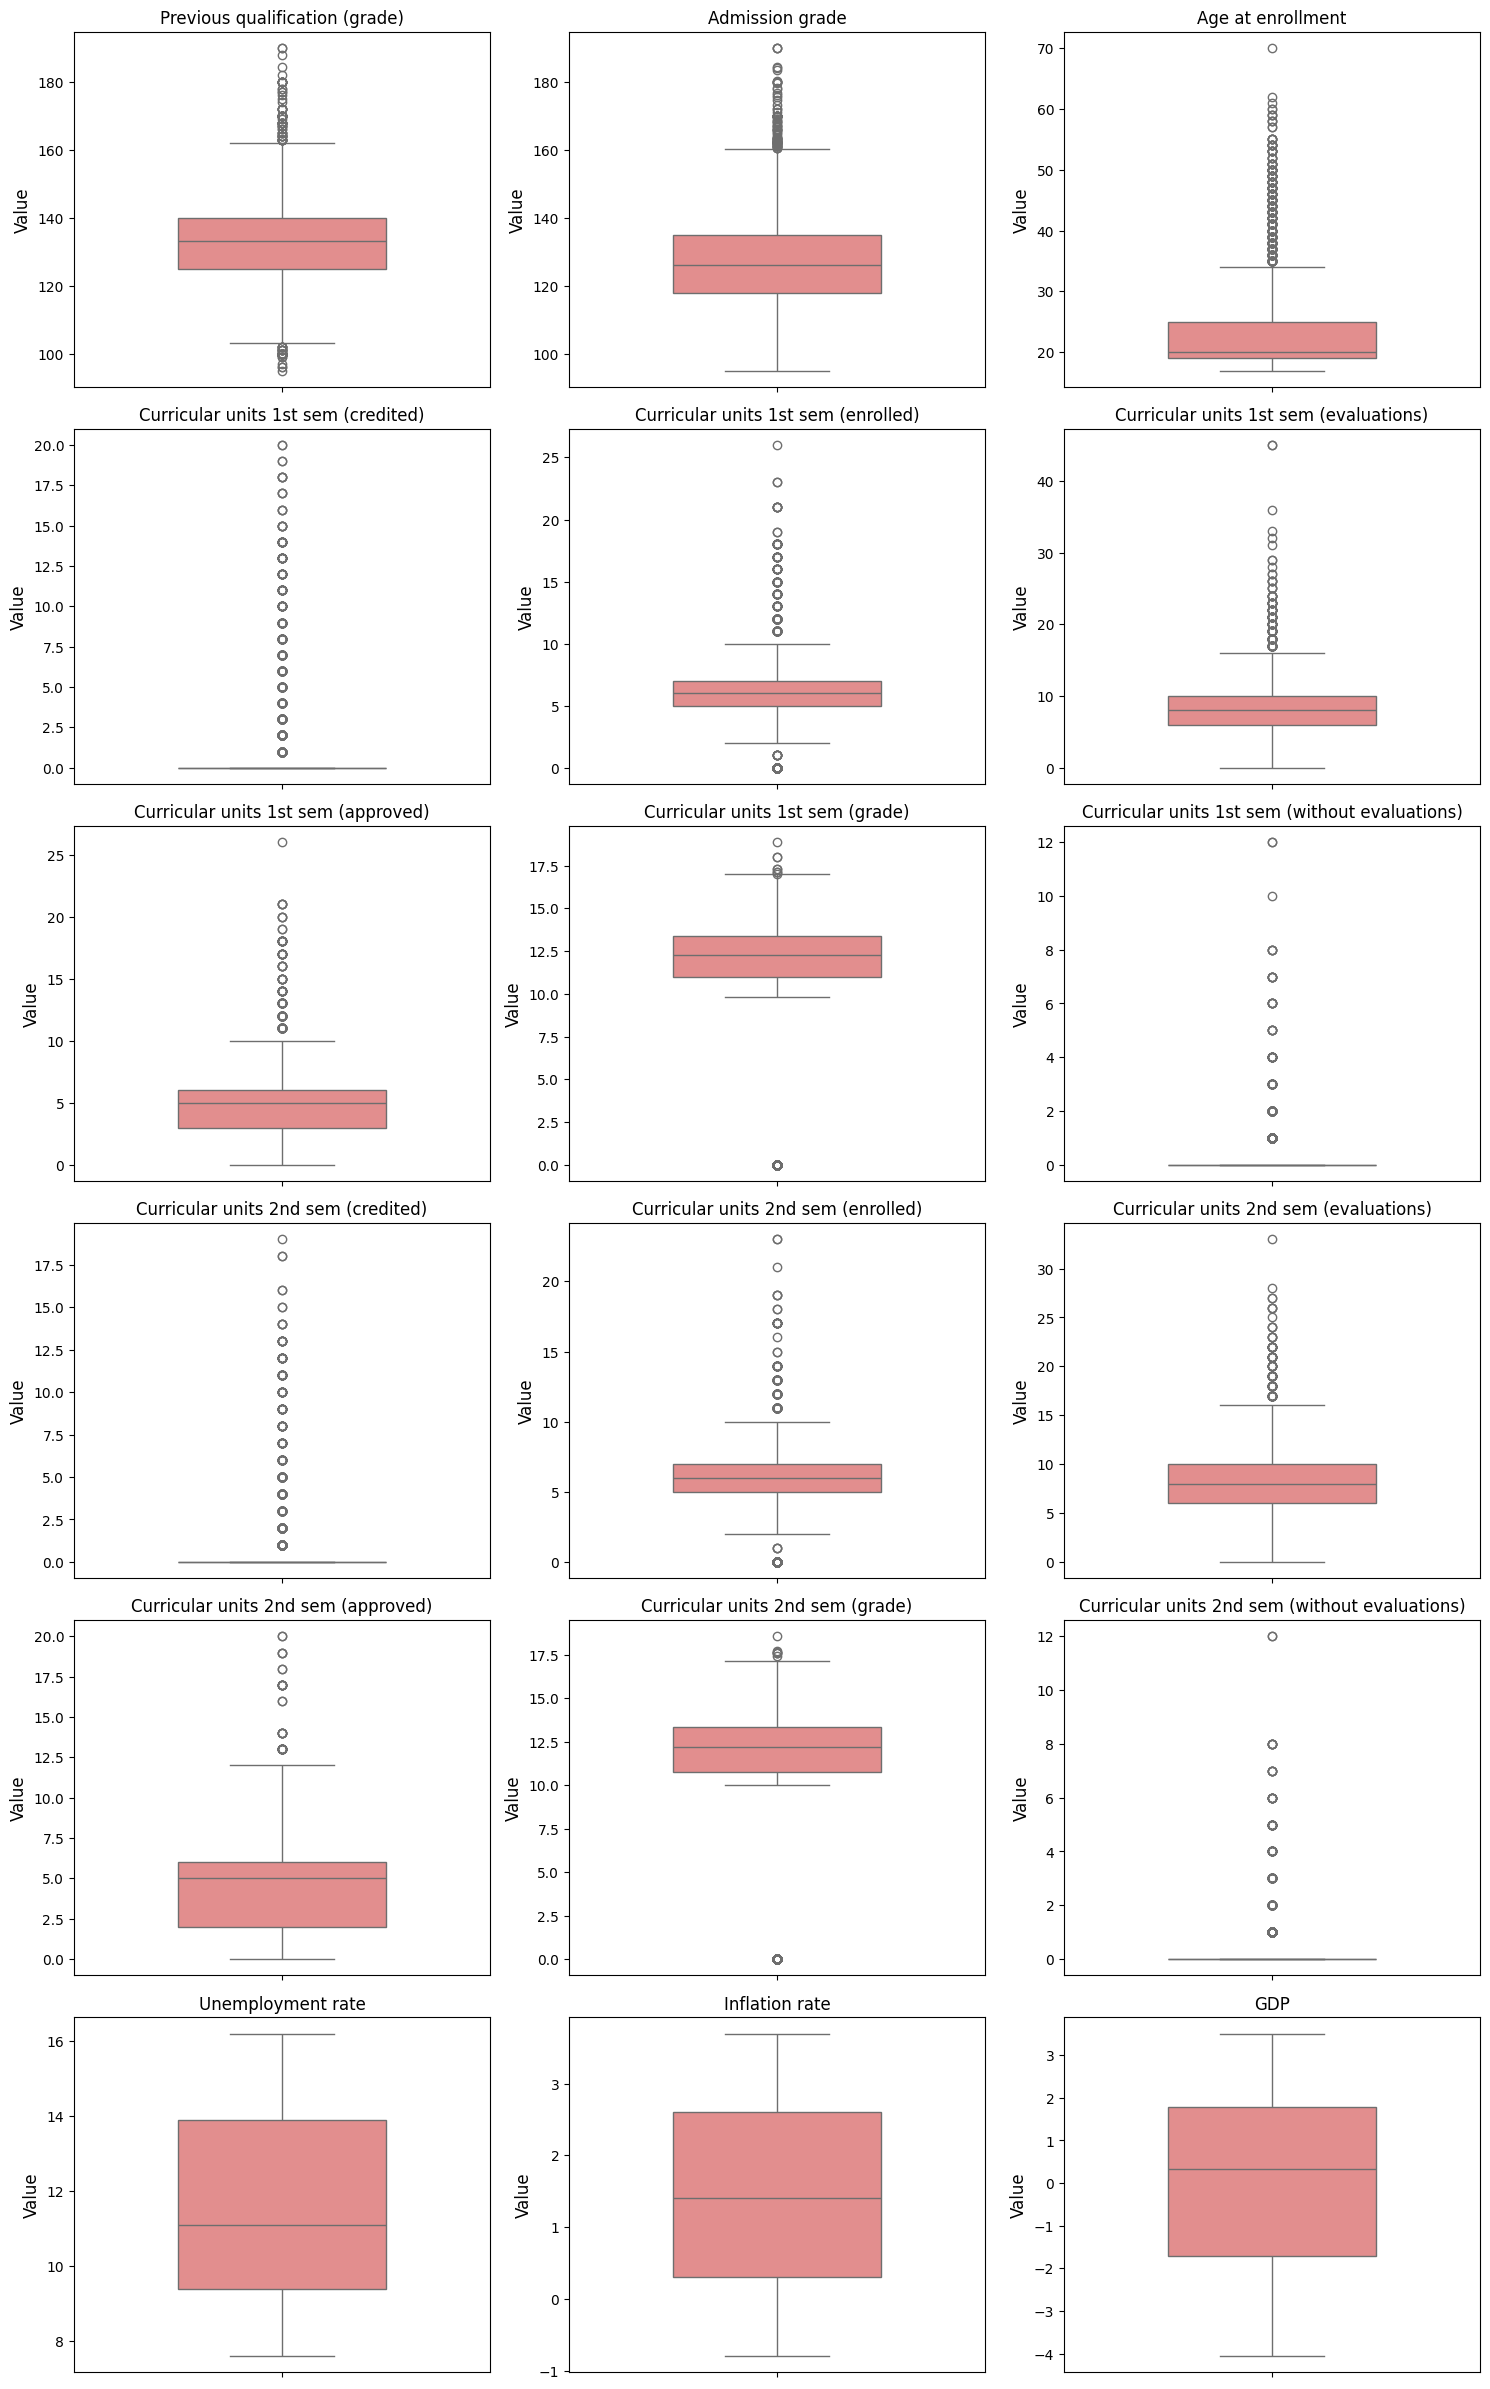

In [8]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Visualize
for i, col in enumerate(numeric_cols):
    sns.boxplot(data[col], 
                ax=axes[i],
                color='lightcoral',
               width=0.5)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Value', fontsize=12)

# Eliminate empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

After generating the initial box plots for the numerical features, a significant number of outliers were identified across several variables: **Age at enrollment**, **Curricular units (credited)** and **Academic grades**.

For academic performance, outliers at the lower bound (Grade = 0) represent thos students who failed or did not attend exams. Those are not real outliers but critical indicators of "Dropout" behavior.

The "Age at enrollment" variable shows a long tail of adult learners (30-50+ years old). These are essential for the model to understand the risk factors associated with those non-traditional' students. Therefore, we consider them important and don't delete them.

Variables like GPD and Inflation show specific economic cycles of the country, they don't appear to have outliers. 

##### **2. Exploratory Data Analysis (EDA)**
##### **2.1 Univariate Analysis: Target**
First, let's analyze the general distribution of our **target variable** to see if the dataset is balanced, and visualize how some key categorical variables behave.

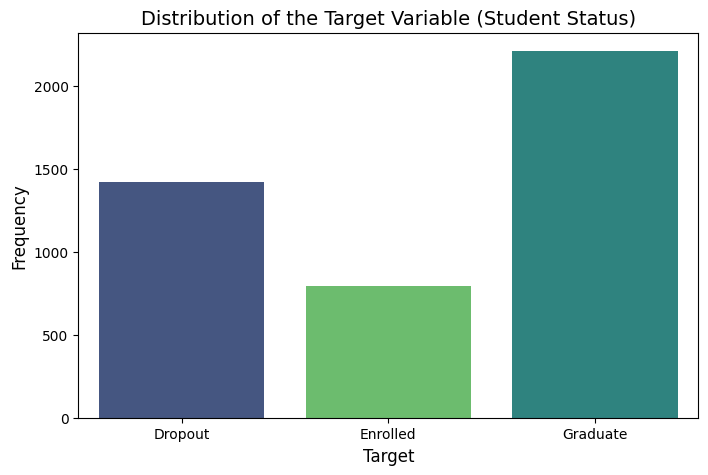

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=data,
    x='Target',
    hue = 'Target',
    palette='viridis', 
    order=['Dropout', 'Enrolled', 'Graduate'],
    legend=False)

plt.title('Distribution of the Target Variable (Student Status)', fontsize=14)
plt.xlabel('Target', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Now, we are going to visualize the **categorical values**

In [10]:
categorical_cols = [col for col in data.columns if col not in numeric_cols and col != 'Target']
display(data[categorical_cols].astype('object').describe())

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International
count,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424,4424
unique,6,18,8,17,2,17,21,29,34,32,46,2,2,2,2,2,2,2
top,1,1,1,9500,1,1,1,1,37,9,9,1,0,0,1,0,0,0
freq,3919,1708,3026,766,3941,3717,4314,1069,1209,1577,1010,2426,4373,3921,3896,2868,3325,4314


##### **2.2 Bivariate Analysis: How do age & admission scores influence dropout rates?**

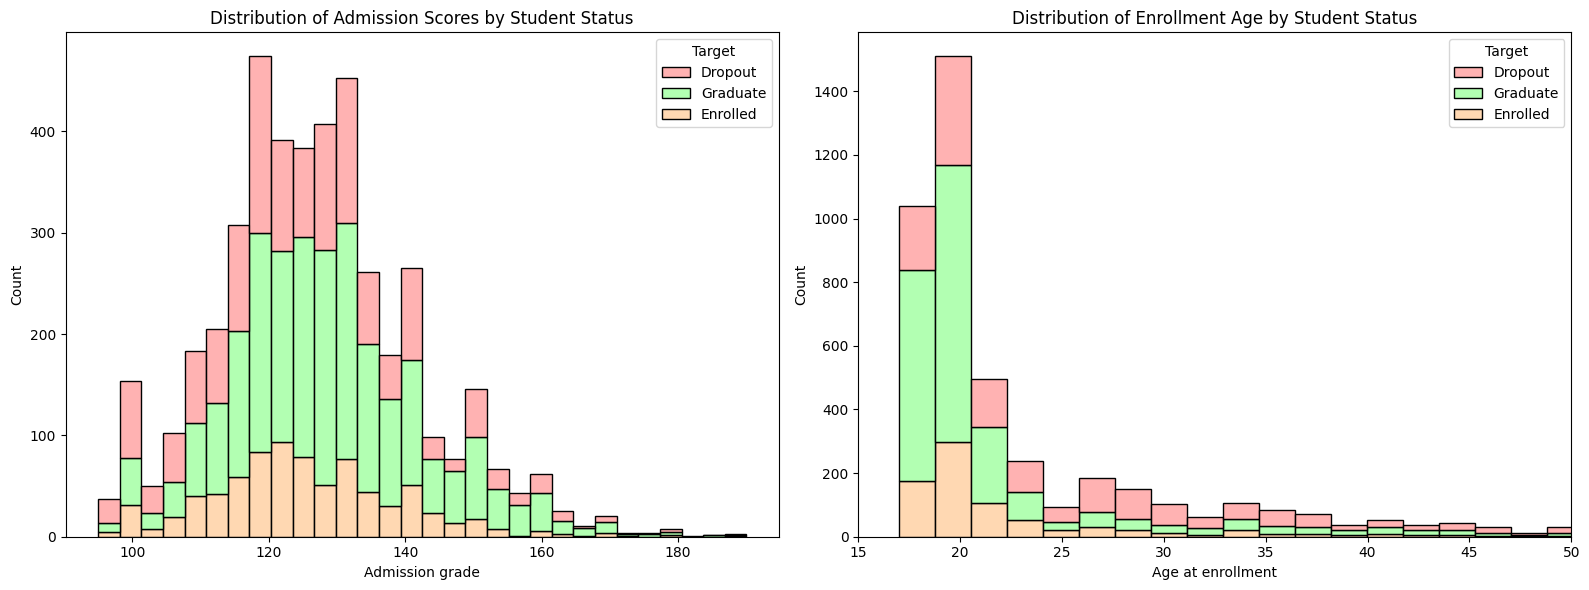

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Admission Scores by Student's State
sns.histplot(data=data, 
             x='Admission grade',
             hue='Target',
             multiple="stack", 
             palette={'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}, 
             ax=axes[0],
             bins=30)

axes[0].set_title('Distribution of Admission Scores by Student Status', fontsize=12)

# Enrollment Age by Student's State
sns.histplot(data=data, 
             x='Age at enrollment',
             hue='Target',
             multiple="stack", 
             palette={'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}, 
             ax=axes[1],
             bins=30)

axes[1].set_title('Distribution of Enrollment Age by Student Status', fontsize=12)

axes[1].set_xlim(15, 50) # We've narrowed down the age range for better visibility
plt.tight_layout()
plt.show()

- **Admission Scores:**
Most students cluster in the 110-140 range. For scores under 120, the dropout rate (red) is noticeably higher than the graduation rate. Once grades pass the 130 mark, the trend reverses completely, with graduates (green) taking a clear lead. Basically, a better entrance score is a strong indicator that the student will stick with the program.

- **Age:**
The 18-20 age group makes up the vast majority of the dataset and shows the highest success rate. However, there's a sharp shift for older students: from age 25 onwards, dropouts heavily outnumber graduates. This makes sense, as older students usually have to balance their degree with jobs or family obligations, making them much more likely to abandon their studies.

##### **2.3 Multivariate Analysis: Correlation Heatmap**

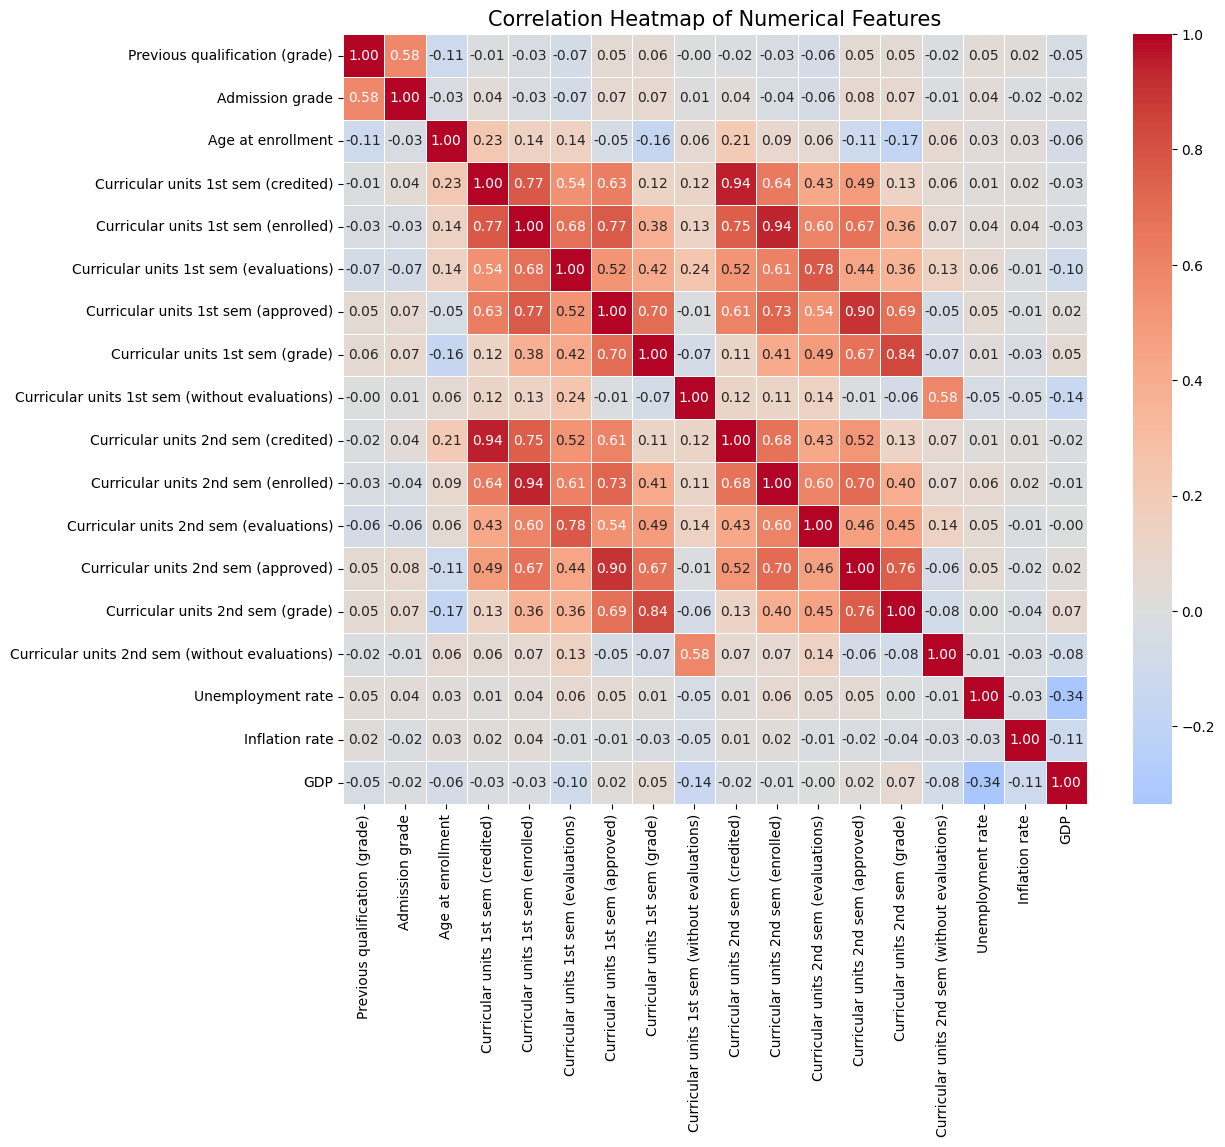

In [12]:
plt.figure(figsize=(12,10))
correlation_matrix = data[numeric_cols].corr()

sns.heatmap(correlation_matrix,
            annot = True,
            cmap = 'coolwarm',
            fmt = '.2f',
            linewidths = 0.5,
            center = 0
           )
plt.title('Correlation Heatmap of Numerical Features', fontsize = 15)
plt.show()

##### **2.4 Correlation with target**
Map Target to numerical values to calculate correlation (Dropout=0, Enrolled=1, Graduate=2)

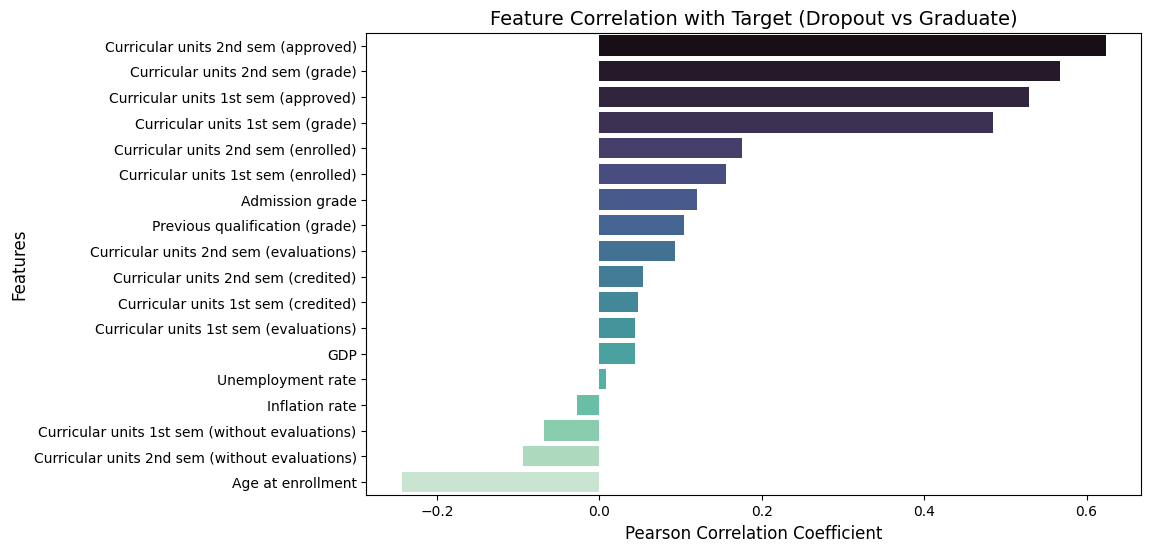

In [13]:
data['Target_num'] = data['Target'].map({'Dropout': 0, 'Enrolled': 1, 'Graduate': 2})
target_corr = data[numeric_cols + ['Target_num']].corr()['Target_num'].drop('Target_num').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values,
            y=target_corr.index,
            hue=target_corr.index,
            palette='mako',
           legend=False)
plt.title('Feature Correlation with Target (Dropout vs Graduate)', fontsize=14)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

# Remove the temporary numerical target column
data = data.drop(columns=['Target_num'])

##### **2.5 Novelty Factor**
We visually investigate how external macroeconomic factors (Inflation, GDP, and Unemployment rate) behave against the student's status. This helps us understand if a bad economic context influences the abandonment of studies.

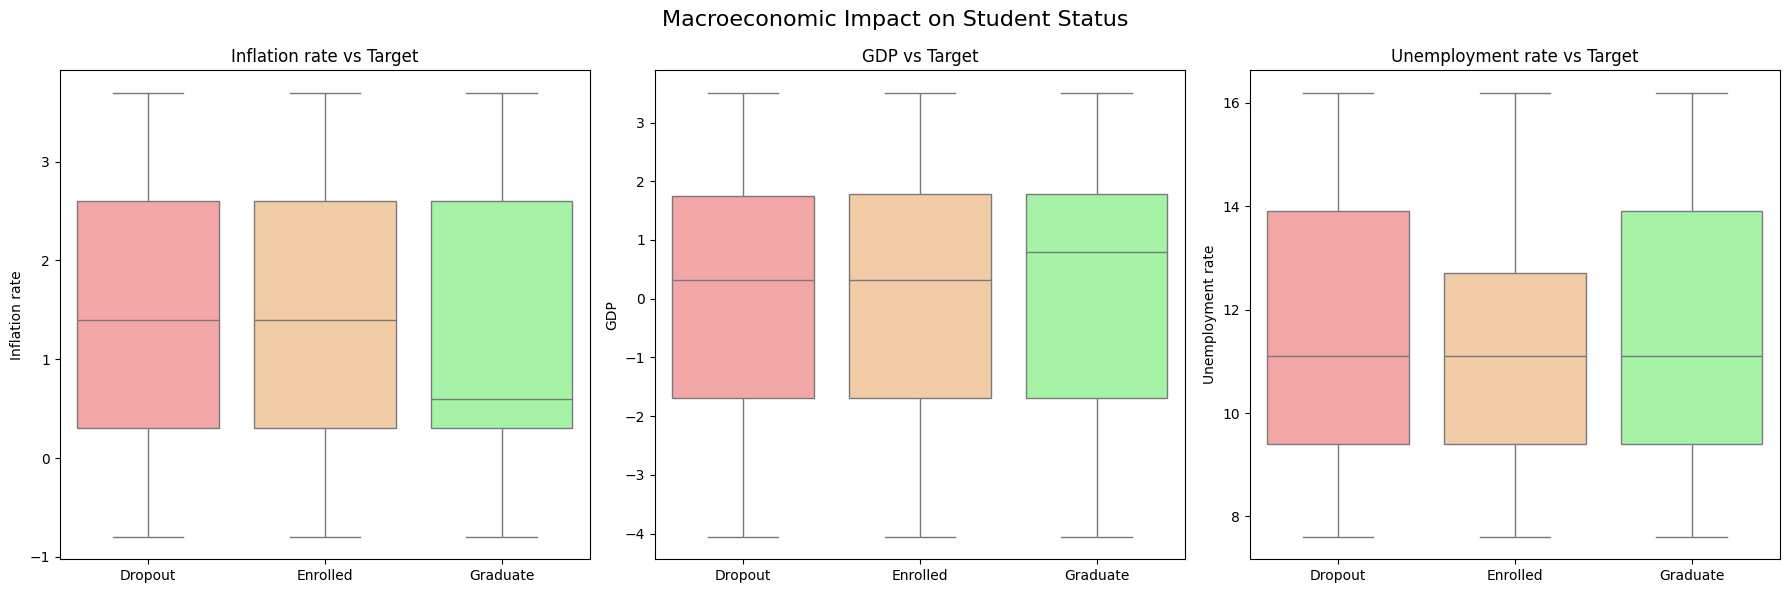

In [14]:
# Boxplots for Macroeconomic variables vs Target
macro_vars = ['Inflation rate', 'GDP', 'Unemployment rate']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Macroeconomic Impact on Student Status', fontsize=16)

palette_colors = {'Dropout': '#ff9999', 'Enrolled': '#ffcc99', 'Graduate': '#99ff99'}
target_order = ['Dropout', 'Enrolled', 'Graduate']

for i, col in enumerate(macro_vars):
    sns.boxplot(ax=axes[i], 
                data=data,
                x='Target',
                y=col,
                hue='Target',
                palette=palette_colors,
                order=target_order,
                legend=False
               )
    axes[i].set_title(f'{col} vs Target', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

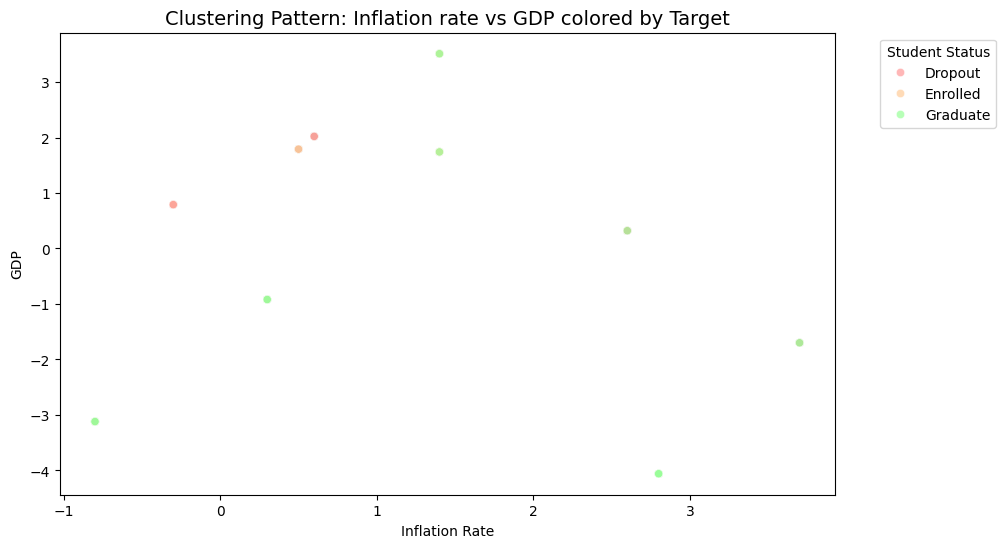

In [15]:
# Scatter plot to find clustering patterns between Inflation and GDP

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data,
                x='Inflation rate',
                y='GDP',
                hue='Target', 
                palette=palette_colors,
                alpha=0.7,
                hue_order=target_order)

plt.title('Clustering Pattern: Inflation rate vs GDP colored by Target', fontsize=14)
plt.xlabel('Inflation Rate')
plt.ylabel('GDP')
plt.legend(title='Student Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

##### **Conclusions regarding the patterns identified:**
* **Curricular Redundancy**: There is a very high correlation between several 1st and 2nd-semester variables (like Curricular units enrolled vs evaluations). We can drop these overlapping features to make the model simpler to interpret without losing predictive power.

* **Academic Impact**: As expected, the number of approved curricular units and the grades obtained are the variables with the strongest positive correlation to student graduation.

* **Macroeconomic Influence (Novelty Factor)**: Looking at the boxplots, dropouts tend to occur more frequently in periods with higher unemployment rates and lower GDP. This suggests that external economic conditions might play an important role in a student's decision to leave university.

##### **3. Feature Selection & Data cleaning**
##### **3.1 Feature Selection**
To ensure model interpretability and avoid multicollinearity (which can confuse the model), we will use the previously obtained Pearson's correlation matrix for numerical variables, using the heatmap to identify and drop redundant variables (features that give the exact same information). Finally, we'll plot a bar chart to see which features provide the most information about our Target. In order to do so, we have to:
* Identify and remove highly correlated variables (Threshold > 0.85)
* Be able to identify two variables that have > 0.85 correlation, if so, they are redundant. We keep one and drop the other.

In [16]:
threshold = 0.85

upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column].abs() > threshold)]

print(f"Highly correlated variables to be dropped (threshold > {threshold}): \n{to_drop}\n")
data = data.drop(columns=to_drop, errors='ignore')

n_before = len(numeric_cols)
numeric_cols = [col for col in numeric_cols if col in data.columns]

print(f"We have eliminated {n_before - len(numeric_cols)} variables for high correlation.")
print(f"We now work with {len(numeric_cols)} numerical variables")


Highly correlated variables to be dropped (threshold > 0.85): 
['Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (approved)']

We have eliminated 3 variables for high correlation.
We now work with 15 numerical variables


##### **3.2 Outlier removal**
We initially attempted to use a standard IQR filter (1.5 * IQR) which resulted in a drastic sample reduction (dropping from 4424 to approximately 2500 records). Such a loss of data, nearly 43% of the dataset, would have introduced a bias making the model only capable of predicting "average" students while ignoring the high-risk profiles.

Consequently, we decided to do a targeted cleaning approach, in which we filtered extreme values that likely represent data entry erros (like impossible amounts of evaluations or credits):

In [17]:
data_og = data.copy()
data_clean = data.copy()

data_clean = data_clean[data_clean['Curricular units 1st sem (evaluations)'] <= 25]
data_clean = data_clean[data_clean['Curricular units 2nd sem (evaluations)'] <= 25]
data_clean = data_clean[data_clean['Curricular units 1st sem (credited)'] <= 15]
data_clean = data_clean[data_clean['Curricular units 1st sem (without evaluations)'] <= 5]

data = data_clean.copy()

print(f"Original lines: {data_og.shape[0]}")
print(f"Lines after cleaning extreme outliers: {data_clean.shape[0]}")

Original lines: 4424
Lines after cleaning extreme outliers: 4380


Because the projects goal is to **predict failure (dropout)**, a surgical data cleaning approach was implemented, resulting in the removal of only 44 records (1.0% of the total dataset). This method was preffered over the standard statistical outlier detection (which would have resulted in a 43% data loss) to preserve the integrity of the non-traditional student profiles essential for predicting dropout. The final dataset contains 4380 high-quality records, ensuring balance bewteen data purity and the retention of critical predictive patterns

##### **3.3 Export Clean Data**

In [18]:
output_path = '../data/processed/data_cleaned.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

data.to_csv(output_path, index=False)
print(f"Dataset saved in {output_path}")

Dataset saved in ../data/processed/data_cleaned.csv


##### **4. Data Preprocessing**
##### **4.1 Importing and visualizing cleaned data**

In [19]:
data_clean = pd.read_csv('../data/processed/data_cleaned.csv')

pd.set_option('display.max_columns', None)
data_clean.head()

print('Cleaned data information:')
data_clean.info()

Cleaned data information:
<class 'pandas.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 34 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4380 non-null   int64  
 1   Application mode                                4380 non-null   int64  
 2   Application order                               4380 non-null   int64  
 3   Course                                          4380 non-null   int64  
 4   Daytime/evening attendance                      4380 non-null   int64  
 5   Previous qualification                          4380 non-null   int64  
 6   Previous qualification (grade)                  4380 non-null   float64
 7   Nacionality                                     4380 non-null   int64  
 8   Mother's qualification                          4380 non-null   int64  
 9   Father's qualification    

##### **4.2 Feature Engineering**
To get better predictions in each model, the following data enginering schema was designed: Feature Engineering: Synthetic Variables Creation.
To ensure all models (Logistic Regression, KNN, SVM, Decision Trees, and Neural Networks) can interpret the data equally and capture hidden mathematical relationships, we created the following synthetic variables.

##### **1. Efficiency Ratios (Academic Performance)**: 
These represent the core of our "early warning system" by measuring the actual success rate of the student.
*   **Success Rate (`success_rate`)**: `Curricular units 1st sem (approved) / (Curricular units 1st sem (enrolled) + 0.0001)`
    *   *Interpretation*: A value close to 1.0 indicates the student is on track (passing everything). A value below 0.5 (failing more than half of their subjects) acts as a massive red flag for the models.

##### **2. Transition Variables (Academic Deltas)**: 
These capture the student's evolution over time, providing linear relationships that greatly benefit Logistic Regression and Neural Networks.
*   **University Shock (`grade_shock`)**: `Curricular units 1st sem (grade) - Admission grade`
    *   *Interpretation*: Measures the difficulty of adaptation. If a student enters with a 16.0 and drops to a 10.0 in the first semester, this strong negative shock is a common precursor to dropping out.

##### **3. Effort or Friction Indexes**: 
These relate the number of times a student takes an exam to the number of subjects they actually pass.
*   **Effort Index (`effort_index`)**: `Curricular units 1st sem (evaluations) / (Curricular units 1st sem (approved) + 0.0001)`
    *   *Interpretation*: Indicates academic frustration. If a student requires 8 evaluations to pass only 2 subjects, it reflects high academic friction and struggle.

##### **4. Socioeconomic Risk (Boolean Interactions)**: 
While Decision Trees can find these splits naturally, providing pre-calculated interactions significantly improves the performance of distance-based models like KNN and SVM.
*   **Extreme Financial Vulnerability (`high_financial_risk`)**: `1 if Debtor == 1 AND Scholarship holder == 0 (else 0)`
    *   *Interpretation*: Directly identifies the most vulnerable group: students who owe money to the university and do not have a scholarship to back them up.
*   **Non-Traditional Student (`is_non_traditional`)**: `1 if Age at enrollment > 23 (else 0)`
    *   *Interpretation*: Students entering university at an older age (outside the standard high school-to-university pipeline) often have additional work or family responsibilities. Their dropout pattern is completely different, and this feature helps models separate them effectively.

---
*Note on Multicollinearity: After computing these synthetic features, the original columns used for calculations (such as `approved`, `evaluations`, and `grade` from the 1st semester) were dropped to prevent multicollinearity, retaining only `enrolled` (to measure absolute volume) and `Admission grade` (to establish the historical baseline).*

In [20]:
#1. Ratios -- Success per semester
data_clean['success_rate'] = data_clean['Curricular units 1st sem (approved)'] / (data_clean['Curricular units 1st sem (enrolled)'] + 0.0001)

#2. Deltas / Academic tendencies
data_clean['grade_shock'] = data_clean['Curricular units 1st sem (grade)'] - data_clean['Admission grade']

#3. Effort indexes
data_clean['effort_index'] = data_clean['Curricular units 1st sem (evaluations)'] / (data_clean['Curricular units 1st sem (approved)'] + 0.0001)

#4. Boolean variables with market risk
data_clean['high_financial_risk'] = ((data_clean['Debtor'] == 1) & (data_clean['Scholarship holder'] == 0)).astype(int)
data_clean['is_non_traditional'] = ((data_clean['Age at enrollment']) > 23).astype(int)

##Multilineality cleaning
cols_to_drop = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (grade)',
]

existing_cols_to_drop = [col for col in cols_to_drop if col in data_clean.columns]
data_clean = data_clean.drop(columns=existing_cols_to_drop)

# 6. Update numeric columns
numeric_cols = [col for col in numeric_cols if col in data_clean.columns]

# 7. Verification
print("New features:", [col for col in ['success_rate', 'grade_shock', 'effort_index', 'high_financial_risk', 'is_non_traditional'] if col in data_clean.columns])
print("Dropped columns:", existing_cols_to_drop)
print("Final shape:", data_clean.shape)
print("NaN in new features:", data_clean[['success_rate', 'grade_shock', 'effort_index', 'high_financial_risk', 'is_non_traditional']].isnull().sum().sum())

New features: ['success_rate', 'grade_shock', 'effort_index', 'high_financial_risk', 'is_non_traditional']
Dropped columns: ['Curricular units 1st sem (approved)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (grade)']
Final shape: (4380, 36)
NaN in new features: 0


##### **4.3 Problem definition (target)**
To create more predictive models, we are going to treat with **Multiclass Classification**

In [21]:
print('Dimensions before filtering:', data_clean.shape[0])

# Multiclass target: Dropout, Enrolled, Graduate
X = data_clean.drop(columns=['Target'])
y = data_clean['Target']

print('X dimensions (features):', X.shape[0])
print('y dimensions (target):', y.shape[0])
print('Target classes:', y.unique())

Dimensions before filtering: 4380
X dimensions (features): 4380
y dimensions (target): 4380
Target classes: <StringArray>
['Dropout', 'Graduate', 'Enrolled']
Length: 3, dtype: str


##### **4.4 Encoding and Standarization**

In [22]:
# Encoding of categorical features #

# 80% Train 20% Test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

categorical_features = [col for col in X.columns if col not in numeric_cols]

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_train = encoder.fit_transform(X_train[categorical_features])
encoded_test = encoder.transform(X_test[categorical_features])

#Convert into DataFrame restoring the column names and original indexes
encoded_cols = encoder.get_feature_names_out(categorical_features)
encoded_train_df = pd.DataFrame(encoded_train, columns = encoded_cols, index = X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns = encoded_cols, index = X_test.index)

#Replace the categorical columns (original ones) with the new ones (encoded)
X_train = pd.concat([X_train.drop(columns=categorical_features), encoded_train_df], axis=1)
X_test = pd.concat([X_test.drop(columns=categorical_features), encoded_test_df], axis=1)

print(f"Encoding complete. New shape of X_train:{X_train.shape}. New shape of x_test: {X_test.shape}")


# Standardization of features #

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Standarization complete.")
print(f"X_train is now ready. Mean of numeric columns is now: {X_train[numeric_cols].mean()}")

Encoding complete. New shape of X_train:(3504, 2653). New shape of x_test: (876, 2653)
Standarization complete.
X_train is now ready. Mean of numeric columns is now: Previous qualification (grade)                   -3.051846e-16
Admission grade                                  -4.755202e-16
Age at enrollment                                -4.359780e-17
Curricular units 1st sem (credited)              -1.318073e-17
Curricular units 1st sem (enrolled)               1.181196e-16
Curricular units 1st sem (without evaluations)   -3.041707e-17
Curricular units 2nd sem (evaluations)            2.230585e-17
Curricular units 2nd sem (grade)                  1.723634e-16
Curricular units 2nd sem (without evaluations)   -2.179890e-17
Unemployment rate                                -9.834852e-17
Inflation rate                                    4.055609e-17
GDP                                               1.115293e-17
dtype: float64


##### **4.5 Export final .csv**

In [23]:
out_dir = '../data/processed'
os.makedirs(out_dir, exist_ok=True)

# unify features + target
train_df = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)],
    axis=1
)

test_df = pd.concat(
    [X_test.reset_index(drop=True), y_test.reset_index(drop=True)],
    axis=1
)

# save
train_df.to_csv(os.path.join(out_dir, 'data_train.csv'), index=False)
test_df.to_csv(os.path.join(out_dir, 'data_test.csv'), index=False)

print("Train and test saved correctly.")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train and test saved correctly.
Train shape: (3504, 2654)
Test shape: (876, 2654)


##### **5. Modelling**
##### **5.1 Logistic Regression**

Logistic Regression Accuracy: 0.7454337899543378
Classification Report:               precision    recall  f1-score   support

     Dropout       0.80      0.75      0.77       294
    Enrolled       0.51      0.35      0.42       167
    Graduate       0.77      0.90      0.83       415

    accuracy                           0.75       876
   macro avg       0.69      0.67      0.67       876
weighted avg       0.73      0.75      0.73       876



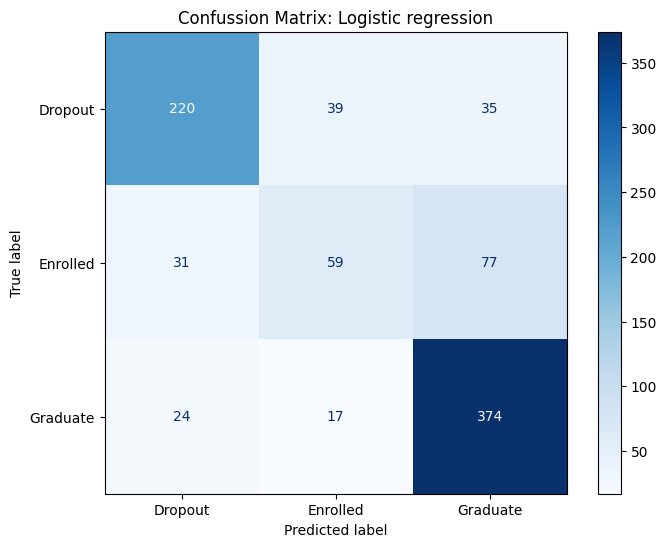

In [24]:
target_col = 'Target'

train_df = pd.read_csv('../data/processed/data_train.csv')
test_df = pd.read_csv('../data/processed/data_test.csv')

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# Start model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Training
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_test)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy}")
print(f"Classification Report: {classification_report(y_test,y_pred)}")

# Confussion Matrix
fig, ax = plt.subplots(figsize=(8,6))
ConfusionMatrixDisplay.from_estimator(log_reg,
                                       X_test,
                                       y_test,
                                       display_labels=log_reg.classes_,
                                       cmap='Blues',
                                       ax=ax
                                      )
ax.set_title('Confussion Matrix: Logistic regression')
plt.show()

##### **5.2 Decision Tree**

Global Accuracy: 0.6986

Classification Report (focus on 'Recall' of Dropout class):
              precision    recall  f1-score   support

     Dropout       0.71      0.76      0.74       294
    Enrolled       0.42      0.08      0.13       167
    Graduate       0.71      0.91      0.79       415

    accuracy                           0.70       876
   macro avg       0.61      0.58      0.55       876
weighted avg       0.65      0.70      0.65       876



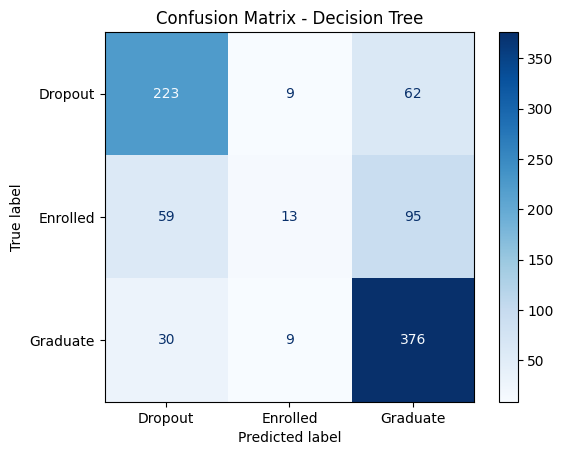

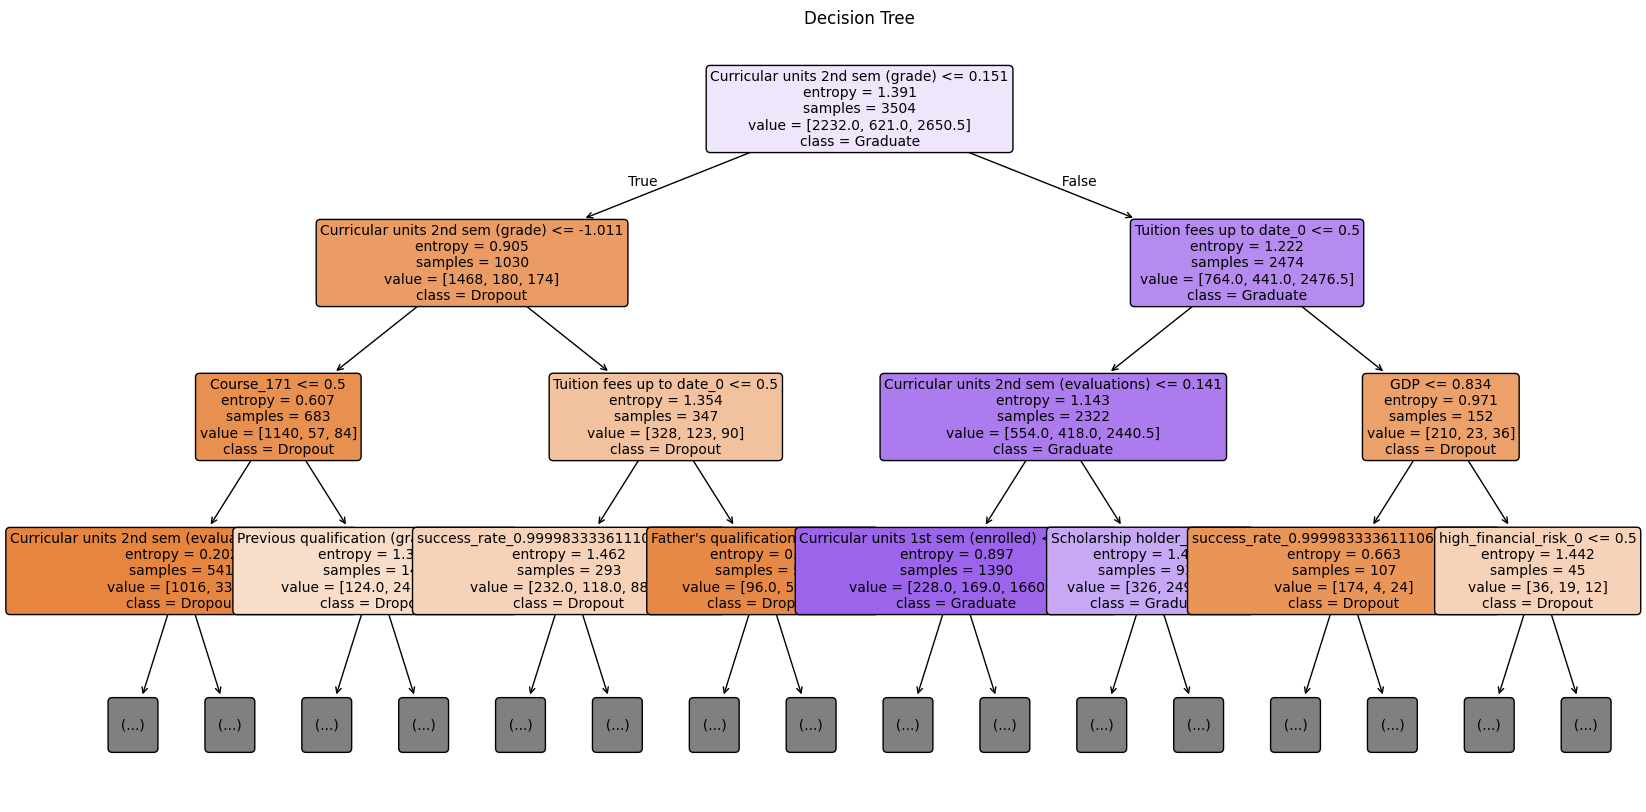

In [25]:
target_col = 'Target'

#Separate predicting variables (X) and objective variables (y)
train_df = pd.read_csv('../data/processed/data_train.csv')
test_df = pd.read_csv('../data/processed/data_test.csv')

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

#start model
custom_weights={
    'Dropout': 2.0,
    'Enrolled': 1.0,
    'Graduate': 1.5
}

clf_tree = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    #class_weight={'Dropout': 4.0, 'Enrolled': 1.0, 'Graduate': 1.0},
    class_weight=custom_weights,
    random_state=42,
)

# Training
clf_tree.fit(X_train, y_train)

# Predict
y_pred = clf_tree.predict(X_test)

# Evaluation of metrics
print(f"Global Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report (focus on 'Recall' of Dropout class):")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf_tree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_tree.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

#Tree visualisation
plt.figure(figsize=(20, 10))
plot_tree(
    clf_tree,
    feature_names=X_train.columns,
    class_names=[str(c) for c in clf_tree.classes_],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3,
)
plt.title("Decision Tree")
plt.show()

##### **5.3 Support Vector Machine (SVM)**

Accuracy: 0.7432

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.84      0.72      0.78       294
    Enrolled       0.53      0.31      0.39       167
    Graduate       0.74      0.93      0.82       415

    accuracy                           0.74       876
   macro avg       0.70      0.66      0.66       876
weighted avg       0.73      0.74      0.73       876



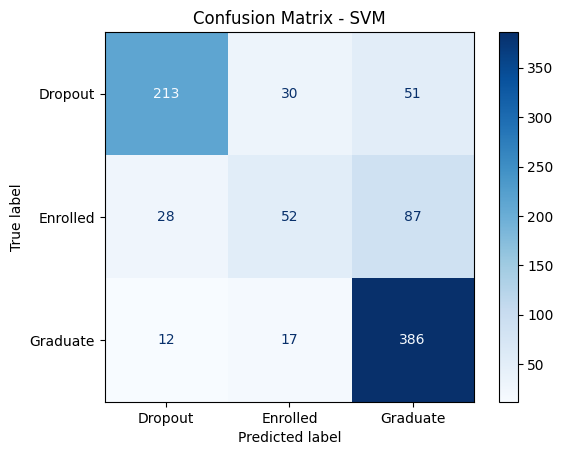

In [26]:
target_col = 'Target'

#Separate predicting variables (X) and objective variables (y)
train_df = pd.read_csv('../data/processed/data_train.csv')
test_df = pd.read_csv('../data/processed/data_test.csv')

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# SVM model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

#Training
svm_model.fit(X_train, y_train)

# Predict
y_pred = svm_model.predict(X_test)

# Evaluation Metrics
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confussion matrix
classes = ['Dropout', 'Enrolled', 'Graduate']
cm = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - SVM")
plt.savefig('cm_svm.png')
plt.show()


##### **5.4 K-Nearest Neighbor**

##### *5.5 Naïve Bayes*


Global Accuracy (Naive Bayes): 0.3037

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.48      0.36      0.41       294
    Enrolled       0.20      0.65      0.30       167
    Graduate       0.51      0.13      0.20       415

    accuracy                           0.30       876
   macro avg       0.39      0.38      0.30       876
weighted avg       0.44      0.30      0.29       876



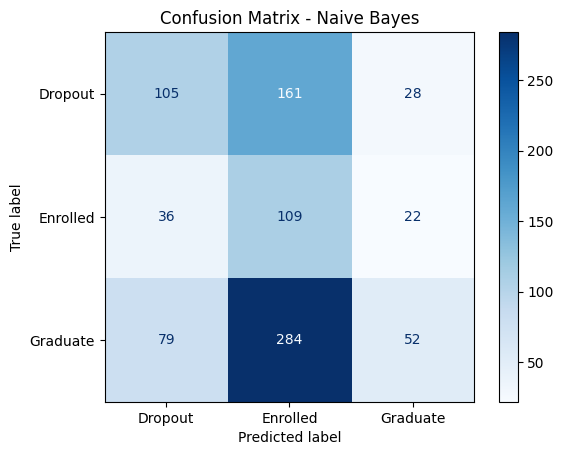

In [29]:
train_df = pd.read_csv('../data/processed/data_train.csv')
test_df = pd.read_csv('../data/processed/data_test.csv')

##Initiate model
nb_model = GaussianNB() #using GaussianNB because numerical variables are already standarised

##Training
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

nb_model.fit(X_train, y_train)

##Predict
y_pred_nb = nb_model.predict(X_test)

##Evaluate metrics
print(f"\nGlobal Accuracy (Naive Bayes): {accuracy_score(y_test, y_pred_nb):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

##Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=nb_model.classes_)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)

disp_nb.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()